### Import Libraries


In [11]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

plt.style.use("ggplot")

### Read the Data

In [6]:
from pathlib import Path

DATA_DIR = Path("../data/train")

DATA_DIR

WindowsPath('../data/train')

In [7]:
DATA_DIR.exists()

True

In [8]:
classes = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])

print("Daftar kelas:")
for cls in classes:
    print("-", cls)

Daftar kelas:
- 0_Recyclable
- 1_Electronic
- 2_Organic


## EDA Procces


### 2.1 - total number of images

In [9]:
from collections import defaultdict

class_counts = defaultdict(int)

for class_folder in DATA_DIR.iterdir():
    if class_folder.is_dir():
        class_counts[class_folder.name] = len(list(class_folder.glob("*")))

counts_df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Jumlah Gambar"]
)

counts_df

,Class,Jumlah Gambar
0,0_Recyclable,9999
1,1_Electronic,3961
2,2_Organic,12567


### 2.2 - total number of images per category

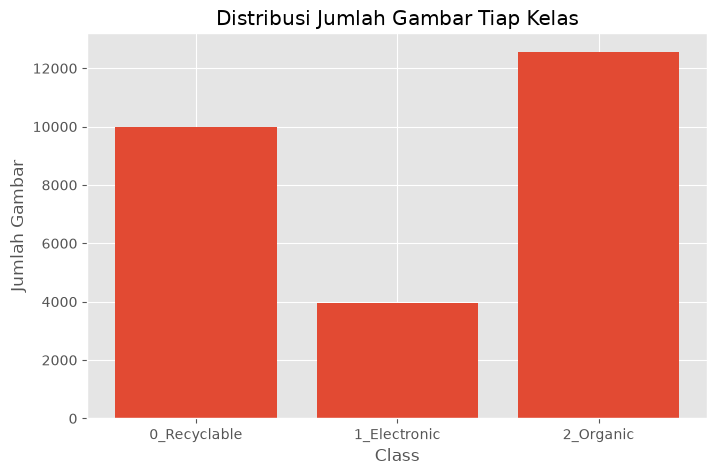

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    counts_df["Class"],
    counts_df["Jumlah Gambar"]
)

plt.title("Distribusi Jumlah Gambar Tiap Kelas")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")

plt.show()

### Isi Dataset

### 2.3 - sample data 

In [13]:
sample_images = {}

for class_folder in DATA_DIR.iterdir():
    if class_folder.is_dir():
        image_path = next(class_folder.glob("*"))
        sample_images[class_folder.name] = image_path

sample_images

{'0_Recyclable': WindowsPath('../data/train/0_Recyclable/R_1.jpg'),
 '1_Electronic': WindowsPath('../data/train/1_Electronic/1-theworldprod.jpg'),
 '2_Organic': WindowsPath('../data/train/2_Organic/O_1.jpg')}

### visualisasi sample data

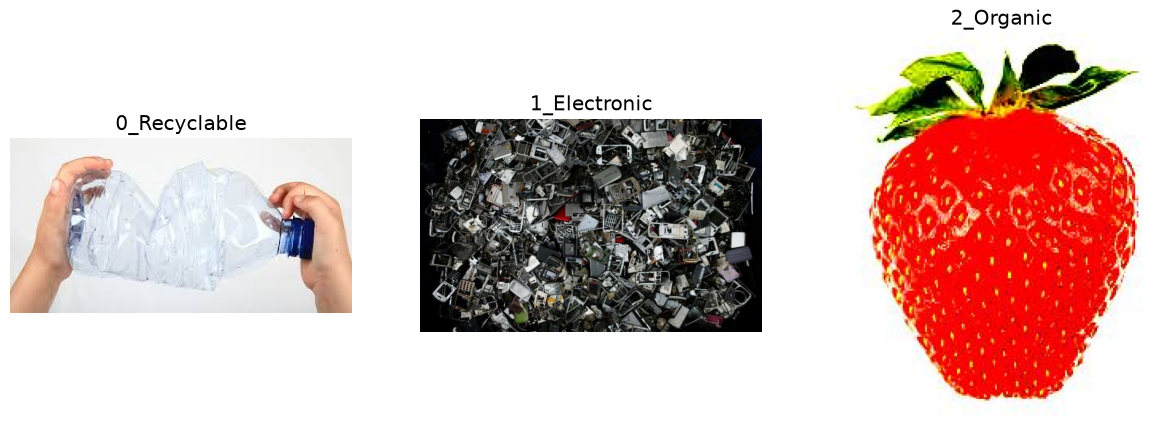

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (class_name, image_path) in zip(axes, sample_images.items()):
    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.show()

### Analisis Aspect Ratio (Rasio Aspek)

In [15]:
image_sizes = []

for class_folder in DATA_DIR.iterdir():
    if class_folder.is_dir():

        for image_path in class_folder.glob("*"):

            with Image.open(image_path) as img:
                width, height = img.size

            image_sizes.append({
                "Class": class_folder.name,
                "Width": width,
                "Height": height
            })

sizes_df = pd.DataFrame(image_sizes)

sizes_df.head()


,Class,Width,Height
0,0_Recyclable,314,160
1,0_Recyclable,300,150
2,0_Recyclable,269,187
3,0_Recyclable,300,168
4,0_Recyclable,315,160


In [18]:
sizes_df.describe()

,Width,Height
count,26527.000000,26527.000000
mean,304.941041,250.227391
std,417.923007,342.697508
min,51.000000,69.000000
25%,220.000000,174.000000
50%,254.000000,194.000000
75%,276.000000,225.000000
max,8000.000000,6000.000000


### Sprint 2.4 — Visualisasi Distribusi Ukuran Gambar

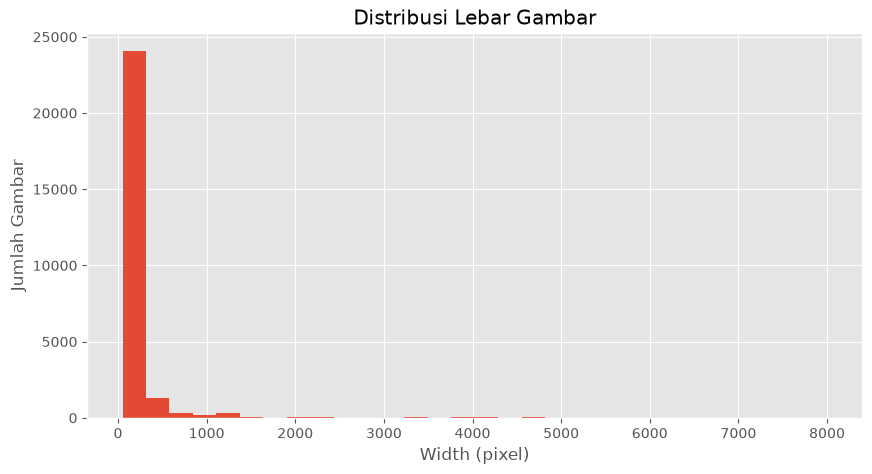

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(sizes_df["Width"], bins=30)

plt.title("Distribusi Lebar Gambar")
plt.xlabel("Width (pixel)")
plt.ylabel("Jumlah Gambar")

plt.show()

### Sprint 2.5 — Analisis Aspect Ratio (Rasio Aspek)

In [20]:
sizes_df["Aspect_Ratio"] = sizes_df["Width"] / sizes_df["Height"]

sizes_df.head()

,Class,Width,Height,Aspect_Ratio
0,0_Recyclable,314,160,1.962500
1,0_Recyclable,300,150,2.000000
2,0_Recyclable,269,187,1.438503
3,0_Recyclable,300,168,1.785714
4,0_Recyclable,315,160,1.968750


### 2.6 — Analisis Kategori Gambar ratio

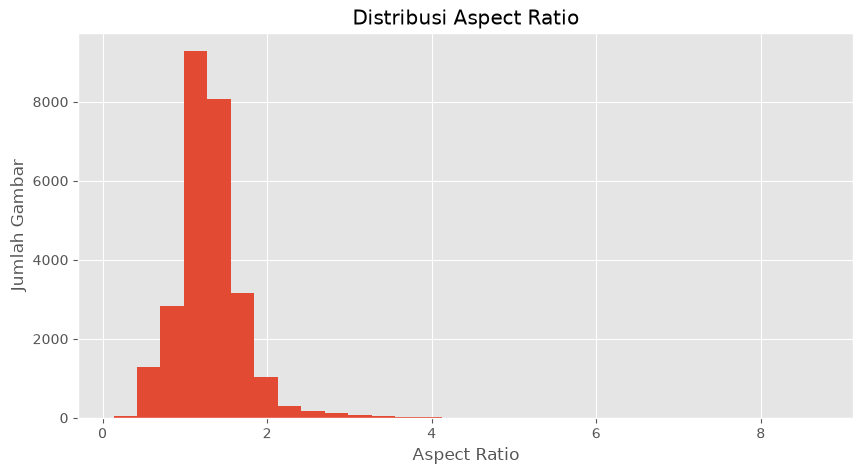

In [21]:
plt.figure(figsize=(10, 5))

plt.hist(sizes_df["Aspect_Ratio"], bins=30)

plt.title("Distribusi Aspect Ratio")
plt.xlabel("Aspect Ratio")
plt.ylabel("Jumlah Gambar")

plt.show()